<a href="https://colab.research.google.com/github/lazarosgogos/ML-exercises/blob/main/ML_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# == FINAL PROJECT - POVERTY PREDICTION CHALLENGE ==

## Load libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.neural_network import MLPRegressor
from scipy.stats import zscore
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import lightgbm as lgb
from lightgbm.sklearn import LGBMRegressor
from sklearn.model_selection import GridSearchCV, PredefinedSplit, GroupKFold
!pip --quiet install perpetual
from perpetual import PerpetualBooster
from perpetual.sklearn import PerpetualRegressor

In [ ]:
parent_path = './drive/MyDrive/MSC-ML-exercises/final-project/'
train_df = pd.read_csv(parent_path + 'train_hh_features.csv')
test_df = pd.read_csv(parent_path + 'test_hh_features.csv')
feature_value_desc_df = pd.read_csv(parent_path + 'feature_value_descriptions.csv')
targets_df_og = pd.read_csv(parent_path + 'train_hh_gt.csv')
targets_df = targets_df_og.drop(columns=['survey_id', 'hhid'])
train_rates_df = pd.read_csv(parent_path + 'train_rates_gt.csv')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 10)
# train_df.head()
train_df.columns

Index(['hhid', 'com', 'weight', 'strata', 'utl_exp_ppp17', 'male', 'hsize',
       'num_children5', 'num_children10', 'num_children18', 'age', 'owner',
       'water', 'toilet', 'sewer', 'elect', 'water_source',
       'sanitation_source', 'dweltyp', 'num_adult_female', 'num_adult_male',
       'num_elderly', 'employed', 'sworkershh', 'share_secondary', 'educ_max',
       'sfworkershh', 'any_nonagric', 'sector1d', 'region1', 'region2',
       'region3', 'region4', 'region5', 'region6', 'region7', 'urban',
       'consumed100', 'consumed200', 'consumed300', 'consumed400',
       'consumed500', 'consumed600', 'consumed700', 'consumed800',
       'consumed900', 'consumed1000', 'consumed1100', 'consumed1200',
       'consumed1300', 'consumed1400', 'consumed1500', 'consumed1600',
       'consumed1700', 'consumed1800', 'consumed1900', 'consumed2000',
       'consumed2100', 'consumed2200', 'consumed2300', 'consumed2400',
       'consumed2500', 'consumed2600', 'consumed2700', 'consumed2800',
 

In [ ]:
train_df.describe()

,hhid,com,weight,strata,utl_exp_ppp17,hsize,num_children5,num_children10,num_children18,age,...,share_secondary,sfworkershh,region1,region2,region3,region4,region5,region6,region7,survey_id
count,104234.000000,104234.0,104234.000000,104234.000000,104149.000000,104234.000000,104234.000000,104234.000000,104234.000000,104234.000000,...,104211.000000,104234.000000,104234.000000,104234.000000,104234.000000,104234.000000,104234.000000,104234.000000,104234.000000,104234.000000
mean,222499.501497,1.0,926.357254,4.424813,510.439284,3.611653,0.287872,0.338066,0.571004,52.589414,...,0.228974,0.320479,0.232736,0.157166,0.106395,0.053150,0.235959,0.098653,0.115941,205059.769365
std,83279.120172,0.0,1121.680081,2.429095,437.475542,1.927880,0.561682,0.598281,0.831472,15.732361,...,0.315510,0.400869,0.422577,0.363959,0.308344,0.224333,0.424599,0.298197,0.320156,81587.641825
min,100001.000000,1.0,2.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,15.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,100000.000000
25%,126059.250000,1.0,270.000000,2.000000,190.115800,2.000000,0.000000,0.000000,0.000000,41.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,100000.000000
50%,219929.500000,1.0,582.000000,5.000000,411.917570,3.000000,0.000000,0.000000,0.000000,52.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,200000.000000
75%,311403.750000,1.0,1128.000000,7.000000,722.440060,5.000000,0.000000,1.000000,1.000000,64.000000,...,0.500000,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,300000.000000
max,337462.000000,1.0,23832.000000,8.000000,5880.471200,21.000000,5.000000,6.000000,6.000000,98.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,300000.000000


## Q1 - Dataset preprocessing

### What changes are to be done to the dataset
Treat each column type differently by filling missing values:
* Binary columns are set to 0, if the value is missing
* Nominal categorical codes are unordered, use the mode (whatever appears most often)
* For counts/discrete quantities, use the median
* For continuous values


In [ ]:
def transform_df(train_df):
  new_df = train_df.copy()
  mapper = feature_value_desc_df.copy()
  col_maps = {
      col: grp.set_index("Value label")['Value'].to_dict()
      for col, grp in mapper.groupby("Variable name")
  }

  for col, mapping in col_maps.items():
    if col in new_df.columns:
      new_df[col] = new_df[col].map(mapping)

  # fill binary values
  binary_cols = [
      c for c in new_df.columns
      if c.startswith('consumed') or c in {
          'male', 'owner', "urban","elect","water","toilet",
          "sewer","employed","any_nonagric"
      }
  ]

  new_df[binary_cols] = new_df[binary_cols].fillna(0)

  # fill nominal columns
  nominal_cols = [
      "dweltyp","educ_max","sector1d",
      "water_source","sanitation_source"
  ]

  for col in nominal_cols:
    if 99 in new_df[col].dropna().unique():
      new_df[col] = new_df[col].fillna(99)
    else:
      new_df[col] = new_df[col].fillna(new_df[col].mode().iloc[0])

  # fill counts/discrete quantities
  count_cols = [
      "hsize","num_children5","num_children10","num_children18",
      "num_adult_female","num_adult_male","num_elderly","age"
  ]

  for col in count_cols:
    new_df[col] = new_df[col].fillna(new_df[col].median())

  # fill continuous values
  share_cols = ["sworkershh","sfworkershh","share_secondary"]
  new_df[share_cols] = new_df[share_cols].fillna(0)

  exp_cols = ["utl_exp_ppp17"] #["cons_ppp17","utl_exp_ppp17"]
  for col in exp_cols:
    new_df[col] = new_df[col].fillna(new_df[col].median())

  # change from different region columns to single region column
  region_cols = [f"region{i}" for i in range(1,8)]

  new_df['region'] = (
      new_df[region_cols]
      .idxmax(axis=1)
      .str.replace("region", "", regex=False)
      .astype("int64")
  )
  assert (new_df[region_cols].sum(axis=1) == 1).all()
  new_df.drop(columns=region_cols, inplace=True)

  for col in new_df.columns:
    if new_df[col].isnull().sum() > 0:
    # print(new_df[col].isnull().sum())
      print(col) # this should print nothing, as there are no null values left
  new_df.drop(columns=["hhid", "com", "weight", "survey_id"], inplace=True)
  return new_df

def poverty_rates(consumption, thresholds):
  return [
      (consumption < z).mean()
      for z in thresholds
  ]

survey_id = train_df["survey_id"].values
weight_df = train_df["weight"].copy()
new_df = transform_df(train_df)
new_df.head()

,strata,utl_exp_ppp17,male,hsize,num_children5,num_children10,num_children18,age,owner,water,toilet,sewer,elect,water_source,sanitation_source,dweltyp,num_adult_female,num_adult_male,num_elderly,employed,sworkershh,share_secondary,educ_max,sfworkershh,any_nonagric,sector1d,urban,consumed100,consumed200,consumed300,consumed400,consumed500,consumed600,consumed700,consumed800,consumed900,consumed1000,consumed1100,consumed1200,consumed1300,consumed1400,consumed1500,consumed1600,consumed1700,consumed1800,consumed1900,consumed2000,consumed2100,consumed2200,consumed2300,consumed2400,consumed2500,consumed2600,consumed2700,consumed2800,consumed2900,consumed3000,consumed3100,consumed3200,consumed3300,consumed3400,consumed3500,consumed3600,consumed3700,consumed3800,consumed3900,consumed4000,consumed4100,consumed4200,consumed4300,consumed4400,consumed4500,consumed4600,consumed4700,consumed4800,consumed4900,consumed5000,region
0,4,594.80627,0,1,0,0,0,75,1,1,1,1,1,1,2,1.0,0,0,1,0.0,0.000000,0.000000,3.0,0.0,0,1.0,1,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,2
1,4,1676.27230,0,2,0,0,0,61,1,1,1,1,1,1,2,1.0,1,0,1,0.0,0.000000,0.000000,6.0,0.0,0,1.0,1,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,2
2,4,506.93719,1,5,0,0,2,49,1,1,1,1,1,1,2,1.0,1,2,0,1.0,0.666667,0.333333,5.0,0.5,1,9.0,1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,2
3,4,824.61786,1,5,0,0,1,58,0,1,1,1,0,1,2,1.0,1,3,0,1.0,1.250000,0.250000,5.0,0.2,1,12.0,1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,2
4,4,351.47644,1,7,1,0,0,57,1,1,1,1,1,1,2,1.0,2,3,1,1.0,0.666667,0.333333,6.0,0.5,1,6.0,1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,2


## Q2 - Dataset analysis

### Column information:
**General Household Information**

* hhid: A unique identifier for each household in the dataset.

* com: A unique identifier for individual members within a household.

* weight: The sampling weight assigned to the household for statistical representation.

* strata: The stratification variable used in the survey design.

* cons_ppp17: The target variable representing per-capita daily expenditure in Purchasing Power Parity (PPP) terms for 2017.

* utl_exp_ppp17: The total expenditure of the household on utilities, measured in 2017 PPP.

* male: Indicates whether the head of the household is male.

* hsize: The total number of members residing in the main household.

* num_children5: The count of children under the age of 5 in the household.

* num_children10: The count of children between the ages of 5 and 10 in the household.

* num_children18: The count of children and adolescents between the ages of 10 and 18 in the household.

* age: The age of the household head in years.

* num_adult_female: The number of female adults aged 18 to 69 in the household.

* num_adult_male: The number of male adults aged 18 to 69 in the household.

* num_elderly: The number of elderly individuals aged 70 or older in the household.

**Dwelling and Infrastructure**
* owner: Indicates whether the household owns their current dwelling.

* water: Indicates if the dwelling has access to a formal water supply system.

* toilet: Indicates the presence of toilet facilities within the dwelling.

* sewer: Indicates whether the toilet facilities are connected to a sewer system.

* elect: Indicates whether the dwelling has access to electricity.

* water_source: Specifies the primary source of drinking water for the household.

* sanitation_source: Identifies the main type of sanitation facility used by the household.

* dweltyp: Categorizes the physical type of the dwelling structure.

* urban: Indicates whether the household is located in an urban or rural area.

**Employment and Education**
* employed: Indicates whether the household head is currently employed.

* sworkershh: The share of adults in the household who are currently working.

* share_secondary: The proportion of adults in the household who have completed secondary education.

* educ_max: The highest education level attained by any member of the household.

* sfworkershh: The share of working adults in the household who are in formal employment.

* any_nonagric: Indicates if any household member works in a non-agricultural sector.

* sector1d: Specifies the employment sector of the household head using the 1-digit ISIC classification.

**Geographic Regions**
* region1 - region7: Binary indicators representing the specific geographic region where the household is located.

**Food Consumption Indicators**
* consumed100 - consumed5000: These binary features indicate whether the household consumed specific food items, including breads, various meats (beef, chicken, pork), grains (rice, corn, quinoa), vegetables, fruits, and dairy products.

**Poverty Benchmarks**
* _pline5 - _pline95: These represent various poverty lines corresponding to specific percentiles (from the 5th to the 95th) of the welfare distribution in the training data.

Feature importance

Correlation plot

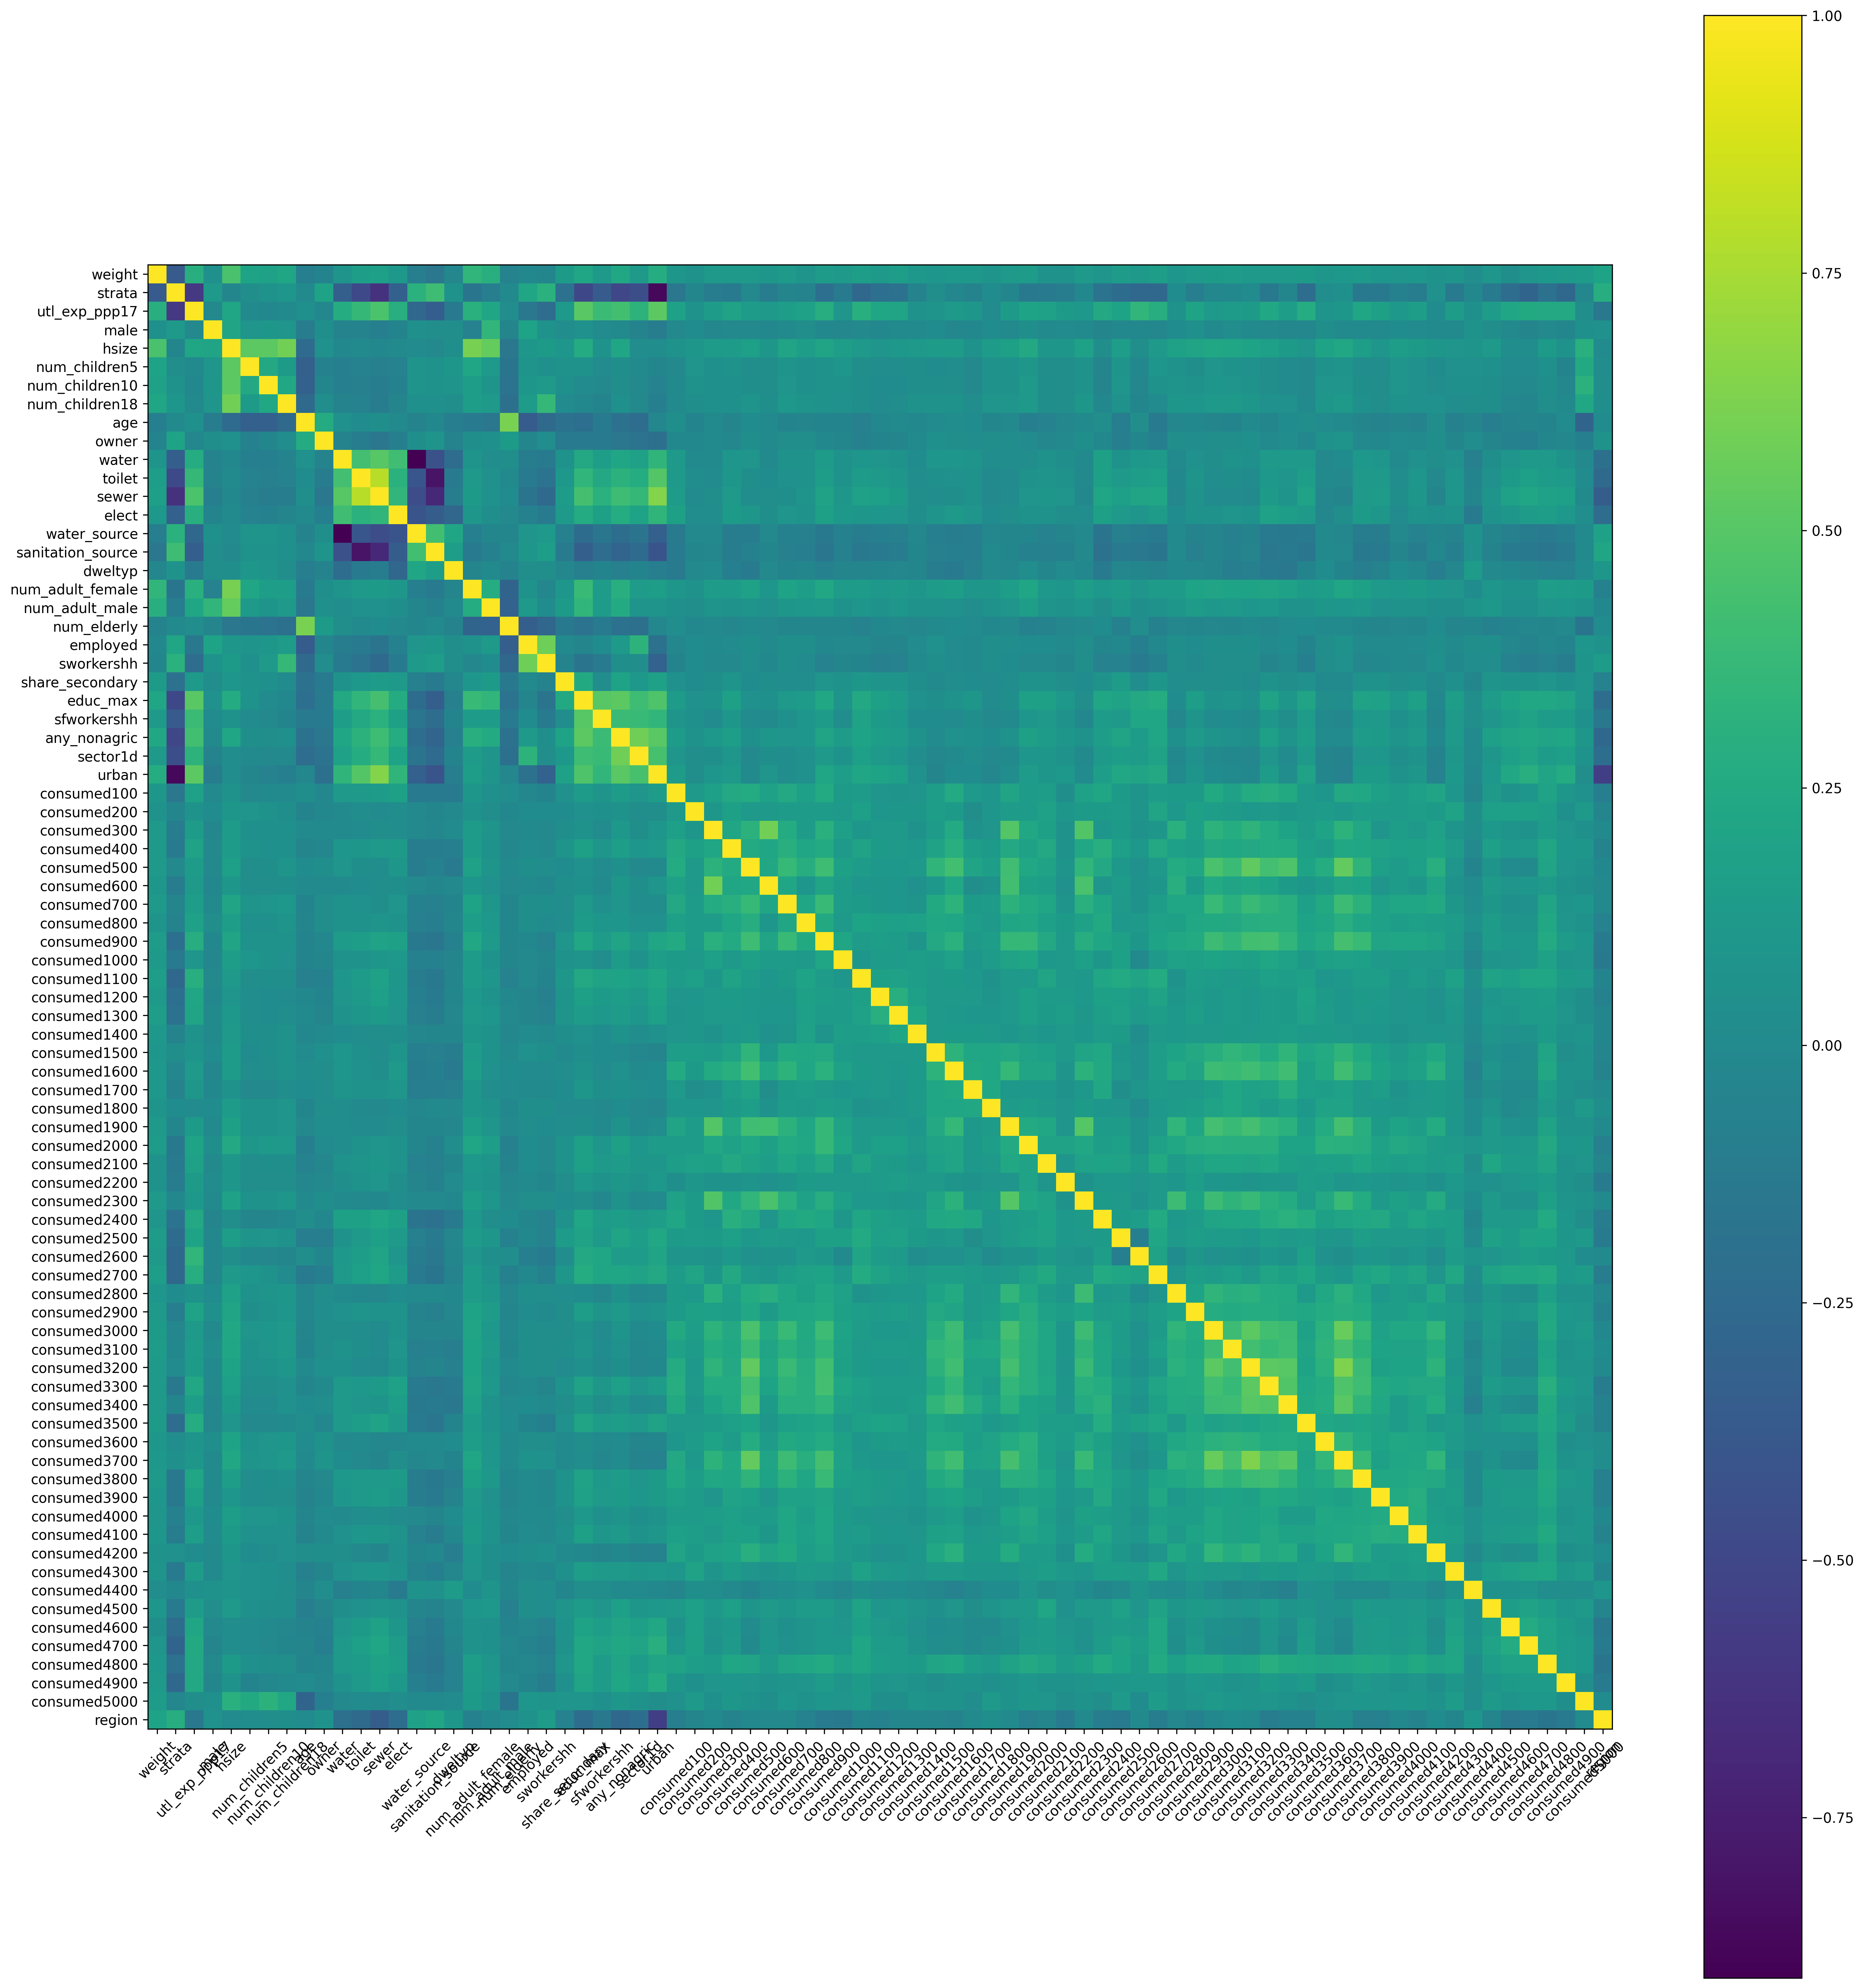

In [ ]:
corr = new_df.corr()
plt.figure(figsize=(20,20), dpi=300)
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr)), corr.columns, rotation=90)
plt.yticks(range(len(corr)), corr.columns)
plt.tight_layout()

## Q3 - Applying 3 different ML algorithms

### Creating a dataset to train on

In [ ]:
X = np.array(new_df)
y = np.array(targets_df).ravel()
test_size = .05
seed = 0
x_train, x_test, y_train, y_test, sid_train, sid_test, weights_train, weights_test = train_test_split(X, y,
                                                    survey_id, weight_df,
                                                    random_state=seed,
                                                    test_size=test_size)
thresholds = [
    3.17, 3.94, 4.60, 5.26, 5.88, 6.47, 7.06, 7.70, 8.40,
    9.13, 9.87, 10.70, 11.62, 12.69, 14.03, 15.64,
    17.76, 20.99, 27.37
]

#### Testing a Random Forest regressor

In [ ]:
rf = RandomForestRegressor()
rf.fit(x_train, y_train, weights_train)
rf.score(x_test, y_test)

0.6313488922098759

#### Testing an eXtreme Gradient Boosting regressor

In [ ]:
xgb = XGBRegressor()
xgb.fit(x_train, y_train, sample_weight=weights_train)
xgb.score(x_test, y_test)

/usr/local/lib/python3.12/dist-packages/xgboost/core.py:771: FutureWarning: Pass `sample_weight` as keyword args.
  warnings.warn(msg, FutureWarning)


0.6432271225744344

#### Testing a K Nearest Neighbors regressor

In [ ]:
knn = KNeighborsRegressor()
knn.fit(x_train, y_train)
knn.score(x_test, y_test, sample_weight=weights_train)

0.20026438477540887

#### Testing a Stochastic Gradient Descent regressor

In [ ]:
sgd = SGDRegressor(loss='huber')
sgd.fit(x_train, y_train)
sgd.score(x_test, y_test)

-2.367274387960472

### Why pick these specific algorithms? What are the results?
We have selected a Random Forest, an XGBoost, a KNeighbors and an SGD regressor, in order to compare various techniques in tabular data prediction.
* **Random Forest**: A Random Forest is a standard way of utilizing Decision Trees to train on tabular data and predict unknown values. It performs adequately, as shown in the table of results below, especially given its short training time (meaning we can iterate and find a better solution by tuning some hyperparameters quite fast).
* **XGBoost**: XGBoost trees are one of the most commonly used models, given they are highly efficient, accurate and able to handle large datasets, by utilizing parallel processing, regularization, and optimized algorithms to build strong models by sequentially combining many weak decision trees. This method proves to be the most effective in this specific task.
* **KNeighbors**: In order to make predictions, this method utilizes local interpolation of the targets associated to the nearest neighbors in the training set.
* **SGD**: The Stochastic Gradient Descent regressor utilizes a linear model under the hood, fitted  by minimizing a regularized empirical loss with SGD. While in different settings SGD is an invaluable technique, it does not appear to work well at all in this given task.

The most adequate model seems to be the XGBoost regressor, out of the ones mentioned above.

#####Grid Search CV approach

In [ ]:
param_grid = {
    "n_estimators": [512, 1024],
    "learning_rate": [.005, .001],
    "num_leaves": [512, 1024],
    "max_depth": [10, 20],
    "min_split_gain": [0.0, 0.25],
    "min_child_samples": [256, 512],
    "seed": [seed],
}
lgb_X_train, lgb_X_val, lgb_y_train, lgb_y_val, lgb_weight_train, lgb_weight_test = train_test_split(
    new_df, y, new_df['weight'],
    test_size=test_size,
    random_state=seed,
)
# combine train + val
X = np.concatenate([lgb_X_train, lgb_X_val])
y = np.concatenate([lgb_y_train, lgb_y_val])
w = np.concatenate([lgb_weight_train, lgb_weight_test])

# -1 = train, 0 = validation
test_fold = np.concatenate([
    -1 * np.ones(len(lgb_X_train), dtype=int),
     np.zeros(len(lgb_X_val), dtype=int)
])

cv = PredefinedSplit(test_fold)

grid_search = GridSearchCV(LGBMRegressor(), param_grid,
                           scoring="neg_mean_absolute_percentage_error",
                           n_jobs=2, cv=cv,
                           verbose=4,)
grid_search.fit(X, y, sample_weight=w)
print(f"The best params: {grid_search.best_params_}")
print(f"The best score: {grid_search.best_score_}")

Fitting 1 folds for each of 64 candidates, totalling 64 fits
[LightGBM] [Debug] Dataset::GetMultiBinFromSparseFeatures: sparse rate 0.789343
[LightGBM] [Debug] Dataset::GetMultiBinFromAllFeatures: sparse rate 0.577837
[LightGBM] [Debug] init for col-wise cost 0.067498 seconds, init for row-wise cost 0.112790 seconds
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.080344 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Debug] Using Sparse Multi-Val Bin
[LightGBM] [Info] Total Bins 1194
[LightGBM] [Info] Number of data points in the train set: 104234, number of used features: 81
[LightGBM] [Info] Start training from score 11.577407
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Debug] Trained a tree with leaves = 92 and depth = 10
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [

In [ ]:
y_val_pred = grid_search.best_estimator_.predict(lgb_X_val)
mape = mean_absolute_percentage_error(lgb_y_val, y_val_pred)
mae = mean_absolute_error(lgb_y_val, y_val_pred)
r2  = r2_score(y_test, y_val_pred)

print(f"MAPE: {mape:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R2 : {r2:.4f}")

MAPE: 0.8616
MAE: 6.4702
R2 : -0.0006


### LGBMRegressor

In [ ]:
# LightGBM

lgb_X_train, lgb_X_val, lgb_y_train, lgb_y_val, lgb_weight_train, lgb_weight_test = train_test_split(
    new_df, y, weight_df,
    test_size=test_size,
    random_state=seed,
)

lgb_train = lgb.Dataset(
    lgb_X_train,
    label=lgb_y_train,
    # categorical_feature=cat_cols,
    free_raw_data=False,
    weight=lgb_weight_train
)

lgb_val = lgb.Dataset(
    lgb_X_val,
    label=lgb_y_val,
    # categorical_feature=cat_cols,
    free_raw_data=False,
    weight=lgb_weight_test
)

params = {
    "objective": "regression",
    "metric": "mape",
    "num_iterations": 500,
    "learning_rate": 0.005,
    "num_leaves": 128,
    "max_depth": 20,
    "min_data_in_leaf": 512,
    "feature_fraction": 0.4,
    # "feature_fraction_by_node":1.0,
    "bagging_fraction": 0.8,
    "bagging_freq": 1,
    "lambda_l1": 0.0,
    "lambda_l2": 1.0,
    "verbosity": -1,
    "seed": seed,
    "early_stopping": 100,
    # "weight": "weight",
    "num_threads": 2,
    # "num_rounds": 200,
    "force_row_wise_true": True,
    # "monotone_constraints": monotone_constraints,
}

gbm = lgb.train(
    params,
    lgb_train,
    num_boost_round=5000,
    # valid_sets=[lgb_train, lgb_val],
    valid_sets=[lgb_train, lgb_val],
    valid_names=["train", "val"],
    # early_stopping_rounds=100,
)

y_val_pred = gbm.predict(lgb_X_val, num_iteration=gbm.best_iteration)

mape = mean_absolute_percentage_error(lgb_y_val, y_val_pred)
mae = mean_absolute_error(lgb_y_val, y_val_pred)
r2  = r2_score(y_test, y_val_pred)

print(f"MAPE: {mape:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R2 : {r2:.4f}")

MAPE: 0.7958
MAE: 6.0335
R2 : 0.3283


### Evaluation metrics

In [ ]:
def wMAPE(true_rates_df, pred_rates_df):
    # rate column names (ventiles)
    rate_cols = list(true_rates_df.columns.drop("survey_id"))

    # 5%, 10%, ..., 95%
    ventiles = np.arange(0.05, 1.00, 0.05)
    weights = 1.0 - np.abs(0.4 - ventiles)
    weights = weights / weights.sum()  # normalize

    # align pred to true by survey_id (preserve order)
    pred_aligned = (
        pred_rates_df.set_index("survey_id")
        .reindex(true_rates_df["survey_id"])
        .reset_index(drop=True)
    )

    wmape_per_survey = []
    for i in range(len(true_rates_df)):
        y_true = true_rates_df.iloc[i][rate_cols].to_numpy(dtype=float)
        y_pred = pred_aligned.iloc[i][rate_cols].to_numpy(dtype=float)

        # handle possible NaNs / zero true rates
        mask = ~np.isnan(y_true) & (y_true > 0)
        if mask.sum() == 0:
            wmape_per_survey.append(0.0)
            continue

        wmape = np.sum(weights[mask] * np.abs(y_true[mask] - y_pred[mask]) / y_true[mask])
        wmape_per_survey.append(wmape)

    return float(np.mean(wmape_per_survey))


def mape(true_hh_df, pred_hh_df):
    merged = true_hh_df.merge(
        pred_hh_df,
        on=["survey_id", "hhid"],
        suffixes=("_true", "_pred")
    )

    y_true = merged["cons_ppp17_true"].to_numpy(dtype=float)
    y_pred = merged["cons_ppp17_pred"].to_numpy(dtype=float)

    mask = ~np.isnan(y_true) & (y_true > 0)
    if mask.sum() == 0:
        return 0.0
    return float(np.mean(np.abs(y_true[mask] - y_pred[mask]) / y_true[mask]))


def metric(true_rates_df, pred_rates_df, true_hh_df, pred_hh_df):
    # true_rates_df: train_rates_df (survey-level ground truth)
    # pred_rates_df: rates_df       (survey-level predictions)
    # true_hh_df   : targets_df_og  (household-level ground truth with survey_id, hhid, cons_ppp17)
    # pred_hh_df   : out_df         (household-level predictions with survey_id, hhid, cons_ppp17)

    rate_error = wMAPE(true_rates_df, pred_rates_df)
    cons_error = mape(true_hh_df, pred_hh_df)

    return 90 * rate_error + 10 * cons_error

def evaluate(y_preds):
  # EVALUATE
  out_df = pd.DataFrame(columns=['survey_id','hhid','cons_ppp17'])

  out_df['survey_id'] = targets_df_og['survey_id'].copy()
  out_df['hhid'] = targets_df_og['hhid'].copy()
  out_df['cons_ppp17'] = y_preds
  rates_df = (
      out_df
      .groupby("survey_id")["cons_ppp17"]
      .apply(lambda x: poverty_rates(x.values, thresholds))
      .reset_index()
  )

  rate_cols = [f"pct_hh_below_{z}" for z in thresholds]

  rates_df[rate_cols] = pd.DataFrame(
      rates_df["cons_ppp17"].tolist(),
      index=rates_df.index
  )

  rates_df.drop(columns=['cons_ppp17'], inplace=True)
  rates_df.columns = train_rates_df.columns
  # CALL (use this exact order)
  score = metric(train_rates_df, rates_df, targets_df_og, out_df)
  return score

# y_preds = gbm.predict(new_df)
y_preds = gbm.predict(new_df)
score = evaluate(y_preds)
print(f"Competition metric for LightGBM: {score:.6f}")


Competition metric for LightGBM: 4.619501


In [ ]:
def create_submission(model, test_df):
  """ This function produces prediction based on the trained model
  and the input data (test_df). It writes the output in 2 .csv files,
  which it then automatically zips into a `submission.zip` file,
  while also deleting the intermediate .csv files.

  Parameters:
    model: the trained model, which will be used to make the predictions
    test_df: a dataframe containing data, in order to make predictions
  """
  out_df = pd.DataFrame(columns=['survey_id','hhid','cons_ppp17'])

  clean_test_df = transform_df(test_df)
  y_preds = model.predict(clean_test_df)
  out_df['survey_id'] = test_df['survey_id'].copy()
  out_df['hhid'] = test_df['hhid'].copy()
  out_df['cons_ppp17'] = y_preds
  out_df.to_csv("predicted_household_consumption.csv", index=False)
  # out_df

  rates_df = (
      out_df
      .groupby("survey_id")["cons_ppp17"]
      .apply(lambda x: poverty_rates(x.values, thresholds))
      .reset_index()
  )

  rate_cols = [f"pct_hh_below_{z}" for z in thresholds]

  rates_df[rate_cols] = pd.DataFrame(
      rates_df["cons_ppp17"].tolist(),
      index=rates_df.index
  )

  rates_df.drop(columns=['cons_ppp17'], inplace=True)
  rates_df.columns = train_rates_df.columns
  rates_df.to_csv("predicted_poverty_distribution.csv", index=False)
  # rates_df
  !zip submission.zip predicted_poverty_distribution.csv predicted_household_consumption.csv
  !rm predicted_household_consumption.csv predicted_poverty_distribution.csv

In [ ]:
# TEST ON ACTUAL DATA
out_df = pd.DataFrame(columns=['survey_id','hhid','cons_ppp17'])

clean_test_df = transform_df(test_df)
y_preds = perp.predict(clean_test_df)
out_df['survey_id'] = test_df['survey_id'].copy()
out_df['hhid'] = test_df['hhid'].copy()
out_df['cons_ppp17'] = y_preds
out_df.to_csv("predicted_household_consumption.csv", index=False)
out_df

,survey_id,hhid,cons_ppp17
0,400000,400001,11.767186
1,400000,400002,6.154041
2,400000,400003,8.928948
3,400000,400004,14.513369
4,400000,400005,4.908821
...,...,...,...
103018,600000,634209,6.583540
103019,600000,634210,4.022352
103020,600000,634211,7.622770
103021,600000,634212,8.540440


### Calculate the CDF of the povery rates

In [ ]:
rates_df = (
    out_df
    .groupby("survey_id")["cons_ppp17"]
    .apply(lambda x: poverty_rates(x.values, thresholds))
    .reset_index()
)

rate_cols = [f"pct_hh_below_{z}" for z in thresholds]

rates_df[rate_cols] = pd.DataFrame(
    rates_df["cons_ppp17"].tolist(),
    index=rates_df.index
)

rates_df.drop(columns=['cons_ppp17'], inplace=True)
rates_df.columns = train_rates_df.columns
rates_df.to_csv("predicted_poverty_distribution.csv", index=False)
rates_df

,survey_id,pct_hh_below_3.17,pct_hh_below_3.94,pct_hh_below_4.60,pct_hh_below_5.26,pct_hh_below_5.88,pct_hh_below_6.47,pct_hh_below_7.06,pct_hh_below_7.70,pct_hh_below_8.40,pct_hh_below_9.13,pct_hh_below_9.87,pct_hh_below_10.70,pct_hh_below_11.62,pct_hh_below_12.69,pct_hh_below_14.03,pct_hh_below_15.64,pct_hh_below_17.76,pct_hh_below_20.99,pct_hh_below_27.37
0,400000,0.016606,0.051381,0.093997,0.145465,0.196210,0.243483,0.290207,0.339071,0.392044,0.440041,0.488240,0.537133,0.587531,0.640388,0.699060,0.753421,0.812672,0.874497,0.939708
1,500000,0.011155,0.039539,0.076770,0.120280,0.165601,0.213549,0.258958,0.307198,0.359001,0.410512,0.458695,0.508717,0.560578,0.617900,0.677092,0.735903,0.797080,0.862637,0.932574
2,600000,0.014322,0.042615,0.080613,0.124485,0.170462,0.214977,0.259141,0.306930,0.356911,0.405957,0.456990,0.508316,0.560401,0.615409,0.675971,0.735130,0.797182,0.862128,0.932686


In [ ]:
!zip submission.zip predicted_poverty_distribution.csv predicted_household_consumption.csv
!rm predicted_household_consumption.csv predicted_poverty_distribution.csv

  adding: predicted_poverty_distribution.csv (deflated 56%)
  adding: predicted_household_consumption.csv (deflated 64%)


### Training an MLP on this data

In [ ]:
# Identify columns for the pipeline
numeric_features = count_cols + share_cols + exp_cols
categorical_features = nominal_cols + ['region']
# binary_cols are already 0/1, so they don't strictly need scaling/encoding

# 2. Create a Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough' # Leaves binary_cols as they are
)

X_processed = preprocessor.fit_transform(new_df)
X_train, X_test, y_train, y_test = train_test_split(X_processed, y,
                                                    test_size=test_size,
                                                    random_state=seed)


In [ ]:
mlp = MLPRegressor(
    hidden_layer_sizes=(128, 64, 64, 32),
    activation='relu',
    solver='adam',
    max_iter=500,
    early_stopping=False,
    shuffle=True,
    verbose=True,
    tol=10**-6
)

mlp.fit(X_train, y_train)
print(f"R^2 Score: {mlp.score(X_test, y_test)}")

Iteration 1, loss = 47.42810292
Iteration 2, loss = 22.97516207
Iteration 3, loss = 21.71865369
Iteration 4, loss = 20.86709620
Iteration 5, loss = 19.89985496
Iteration 6, loss = 20.26862029
Iteration 7, loss = 20.07463974
Iteration 8, loss = 19.28782910
Iteration 9, loss = 19.16548330
Iteration 10, loss = 19.07871297
Iteration 11, loss = 19.66837330
Iteration 12, loss = 19.03937163
Iteration 13, loss = 18.79743409
Iteration 14, loss = 18.87308651
Iteration 15, loss = 18.73783893
Iteration 16, loss = 18.39763467
Iteration 17, loss = 18.48269452
Iteration 18, loss = 18.38528725
Iteration 19, loss = 18.15237672
Iteration 20, loss = 19.14431082
Iteration 21, loss = 17.94182424
Iteration 22, loss = 18.20303232
Iteration 23, loss = 18.02976078
Iteration 24, loss = 17.93572085
Iteration 25, loss = 18.22312581
Iteration 26, loss = 17.65486370
Iteration 27, loss = 17.56333685
Iteration 28, loss = 17.41645338
Iteration 29, loss = 17.74780514
Iteration 30, loss = 17.64806940
Iteration 31, loss 

### Improving the NN architecture and calculating the CDF

In [ ]:
# NN goes here
cat_cols = ["region", "educ_max", "dweltyp", "sector1d"]
cat_cardinalities = {
    "region": 7,
    "educ_max": 7,
    "dweltyp": 10,
    "sector1d": 17
}
cat_embed_dims = {
    "region": 3,
    "educ_max": 4,
    "dweltyp": 4,
    "sector1d": 6
}
binary_cols = [
    c for c in new_df.columns
    if c.startswith("consumed") or c in {
        "male","owner","urban","elect","water",
        "toilet","sewer","employed","any_nonagric"
    }
]
num_cols = [
    c for c in new_df.columns
    if c not in cat_cols + binary_cols
]
X_num_train = x_train[:, [new_df.columns.get_loc(c) for c in num_cols]]
X_bin_train = x_train[:, [new_df.columns.get_loc(c) for c in binary_cols]]

X_num_test  = x_test[:,  [new_df.columns.get_loc(c) for c in num_cols]]
X_bin_test  = x_test[:,  [new_df.columns.get_loc(c) for c in binary_cols]]
X_cat_train = {
    col: x_train[:, new_df.columns.get_loc(col)].astype("int32") - 1
    for col in cat_cols
}

X_cat_test = {
    col: x_test[:, new_df.columns.get_loc(col)].astype("int32") - 1
    for col in cat_cols
}
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping
num_in = layers.Input(shape=(X_num_train.shape[1],), name="numeric")
bin_in = layers.Input(shape=(X_bin_train.shape[1],), name="binary")

cat_inputs = {
    col: layers.Input(shape=(1,), name=col)
    for col in cat_cols
}
cat_embeds = []

for col in cat_cols:
    emb = layers.Embedding(
        input_dim=cat_cardinalities[col],
        output_dim=cat_embed_dims[col],
        name=f"{col}_emb"
    )(cat_inputs[col])

    emb = layers.Flatten()(emb)
    cat_embeds.append(emb)
x = layers.Concatenate()(
    [num_in, bin_in] + cat_embeds
)
x = layers.Dense(256, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)

x = layers.Dense(128, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)

x = layers.Dense(64, activation="relu")(x)
x = layers.BatchNormalization()(x)

x = layers.Dense(32, activation="relu")(x)

out = layers.Dense(1, name="cons_ppp17")(x)
model = Model(
    inputs=[num_in, bin_in] + list(cat_inputs.values()),
    outputs=out
)
model.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=1e-3,
        weight_decay=1e-4
    ),
    loss=tf.keras.losses.Huber(delta=1.0),
    metrics=["mae"]
)
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

history = model.fit(
    {
        "numeric": X_num_train,
        "binary": X_bin_train,
        **X_cat_train
    },
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=256,
    # callbacks=[early_stop],
    verbose=1
)
test_loss, test_mae = model.evaluate(
    {
        "numeric": X_num_test,
        "binary": X_bin_test,
        **X_cat_test
    },
    y_test,
    verbose=0
)

print("Test loss:", test_loss)
print("Test MAE:", test_mae)
y_pred = model.predict(
    {
        "numeric": X_num_test,
        "binary": X_bin_test,
        **X_cat_test
    }
).ravel()


Epoch 1/100
229/229 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - loss: 6.0893 - mae: 6.5629 - val_loss: 4.1942 - val_mae: 4.6515
Epoch 2/100
229/229 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 3.4657 - mae: 3.9222 - val_loss: 3.4871 - val_mae: 3.9414
Epoch 3/100
229/229 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 3.2723 - mae: 3.7263 - val_loss: 3.1537 - val_mae: 3.6047
Epoch 4/100
229/229 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 3.2095 - mae: 3.6611 - val_loss: 3.1973 - val_mae: 3.6442
Epoch 5/100
229/229 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 3.1231 - mae: 3.5752 - val_loss: 2.9932 - val_mae: 3.4401
Epoch 6/100
229/229 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 3.0971 - mae: 3.5481 - val_loss: 2.9220 - val_mae: 3.3727
Epoch 7/100
229/229 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 3.0423 - mae: 3.4931 - val_loss: 3.2220 - val_mae: 3.6678
Epoch 8/100
229/229 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 3.0883 - mae: 3.5395 - val_loss: 2.9238 - val_mae: 3.3780
Epoch 9/100
229/229 ━━━━━━━━━━━━━━━━━━━━ 1s 4

In [ ]:
pred_df = pd.DataFrame({
    "survey_id": sid_test,
    "cons_pred": y_pred
})
pred_rates = (
    pred_df
    .groupby("survey_id")
    .apply(lambda g: [(g["cons_pred"] < t).mean() for t in thresholds])
)

pred_rates = pd.DataFrame(
    pred_rates.tolist(),
    index=pred_rates.index,
    columns=[f"pct_hh_below_{t}" for t in thresholds]
)

train_rates_df = train_rates_df.set_index("survey_id")

pred_rates, gt_rates = pred_rates.align(
    train_rates_df, join="inner"
)

curve_mse = ((pred_rates - gt_rates) ** 2).mean().mean()
print("Poverty curve MSE:", curve_mse)

Poverty curve MSE: 0.0015427632450677887


/tmp/ipython-input-3755134485.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: [(g["cons_pred"] < t).mean() for t in thresholds])


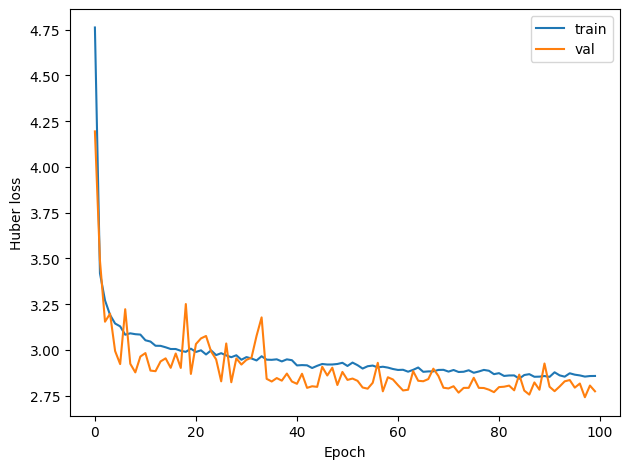

In [ ]:
plt.figure()
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.xlabel("Epoch")
plt.ylabel("Huber loss")
plt.legend()
plt.tight_layout()
plt.show()

### Key takeaways
As is empirically shown, the most potent models are the tree-based ones. The worst contender is the MLP/Neural Networks. No matter how they are trained, they do not perform well, nor can they outdo the tree-based models in tabular data regression. Even after 200+ epochs of training, they cannot outperform a Random Forest Regression, which would take less than 2 minutes (without requiring a GPU), in contrast to the Neural Network, which requires a GPU in order to be trained.